## Checking Sale Price vs Assessed Value

Here we write up a file comparing sale price of homes sold in 2024,2025 and 2026 against their assessed value in 2025 and plot the residuals.

In [1]:
import pandas as pd
import numpy as np

In [2]:
Sale_Prices = pd.read_csv("Parcel_Sales.csv")

In [3]:
Sale_Prices

,pin,year,township_code,neighborhood_code,class,sale_price
0,25151190190000,2026,70,70210,241,"$15,000"
1,20362090240000,2026,70,70080,203,"$170,000"
2,25021140050000,2026,70,70121,202,"$74,657"
3,20142170411003,2026,70,70020,299,"$290,000"
4,25343120590000,2026,70,70260,201,"$200,000"
...,...,...,...,...,...,...
72828,16224060330000,2024,77,77091,211,"$371,035"
72829,17063160150000,2024,77,77052,211,"$875,000"
72830,14311270170000,2024,77,77170,207,"$1,225,000"
72831,16224230200000,2024,77,77092,211,"$268,000"


In [4]:
Assessed_Value_Single_Family_Homes = pd.read_csv("Edited_Chicago_Property_Data.csv")

In [5]:
Assessed_Value_Single_Family_Homes

,pin,tax_year_x,class_x,township_code_x,township_name,neighborhood_code,board_tot,year_built,building_sqft,land_sqft,...,num_half_baths,num_fireplaces,type_of_residence,garage_size,basement_type,ext_wall_material,central_heating,basement_finish,roof_material,central_air
0,26083130030000,2025,203,70,Hyde Park,70240,114010,1908.0,"1,271","3,050",...,0.0,0.0,1.5 Story,2 cars,Partial,Frame + Masonry,Hot Water Steam,Unfinished,Shingle + Asphalt,No Central A/C
1,26083120410000,2025,204,70,Hyde Park,70240,124000,1888.0,"2,055","3,125",...,0.0,0.0,1.5 Story,2 cars,Full,Frame,Warm Air Furnace,Unfinished,Shingle + Asphalt,No Central A/C
2,26083120400000,2025,203,70,Hyde Park,70240,114000,1903.0,"1,188","3,125",...,0.0,0.0,1 Story,2 cars,Full,Frame,Hot Water Steam,Formal Rec Room,Shingle + Asphalt,No Central A/C
3,26083120370000,2025,203,70,Hyde Park,70240,104000,1898.0,"1,321","3,125",...,1.0,0.0,1 Story,1.5 cars,Full,Frame,Hot Water Steam,Unfinished,Shingle + Asphalt,No Central A/C
4,26083120360000,2025,202,70,Hyde Park,70240,70000,1888.0,714,"3,125",...,0.0,0.0,1 Story,1.5 cars,Full,Frame + Masonry,Warm Air Furnace,Unfinished,Shingle + Asphalt,No Central A/C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293767,16021210040000,2025,203,77,West Chicago,77020,254270,1959.0,"1,020","3,100",...,0.0,0.0,1 Story,0 cars,Slab,Frame,Warm Air Furnace,Unfinished,Shingle + Asphalt,No Central A/C
293768,16021210030000,2025,203,77,West Chicago,77020,270000,1963.0,"1,020","3,100",...,0.0,0.0,1 Story,2 cars,Full,Masonry,Warm Air Furnace,Formal Rec Room,Shingle + Asphalt,Central A/C
293769,16021210020000,2025,203,77,West Chicago,77020,260000,1959.0,"1,020","3,100",...,0.0,0.0,1 Story,0 cars,Slab,Frame,Warm Air Furnace,Unfinished,Shingle + Asphalt,No Central A/C
293770,16021200400000,2025,203,77,West Chicago,77020,270000,1960.0,"1,142","2,976",...,1.0,0.0,1.5 Story,1 cars,Full,Frame,Warm Air Furnace,Unfinished,Shingle + Asphalt,Central A/C


In [6]:
Assesed_And_Sale_Price_Data = pd.merge(left = Assessed_Value_Single_Family_Homes, right = Sale_Prices, on = "pin")

In [7]:
Assesed_And_Sale_Price_Data

,pin,tax_year_x,class_x,township_code_x,township_name,neighborhood_code_x,board_tot,year_built,building_sqft,land_sqft,...,ext_wall_material,central_heating,basement_finish,roof_material,central_air,year,township_code,neighborhood_code_y,class,sale_price
0,26083120230000,2025,203,70,Hyde Park,70240,164000,1918.0,"1,397","3,125",...,Frame + Masonry,Warm Air Furnace,Unfinished,Shingle + Asphalt,No Central A/C,2024,70,70240,211,"$145,000"
1,26083110300000,2025,203,70,Hyde Park,70240,190000,1966.0,"1,080","3,125",...,Masonry,Warm Air Furnace,Unfinished,Shingle + Asphalt,Central A/C,2025,70,70240,203,"$145,000"
2,26083110240000,2025,203,70,Hyde Park,70240,134000,1964.0,"1,040","3,117",...,Masonry,Warm Air Furnace,Unfinished,Shingle + Asphalt,No Central A/C,2024,70,70240,203,"$235,100"
3,26083100330000,2025,202,70,Hyde Park,70240,55820,1951.0,952,"3,125",...,Frame,Warm Air Furnace,Unfinished,Shingle + Asphalt,Central A/C,2024,70,70240,202,"$135,000"
4,26083100320000,2025,202,70,Hyde Park,70240,55820,1951.0,952,"3,125",...,Frame,Warm Air Furnace,Unfinished,Shingle + Asphalt,Central A/C,2024,70,70240,202,"$135,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,16021220470000,2025,207,77,West Chicago,77020,628010,2023.0,"1,823","2,507",...,Frame,Warm Air Furnace,Formal Rec Room,Other,Central A/C,2024,77,77020,207,"$628,000"
20396,16021220460000,2025,207,77,West Chicago,77020,710010,2023.0,"1,900","2,601",...,Frame,Warm Air Furnace,Formal Rec Room,Other,Central A/C,2024,77,77020,207,"$640,000"
20397,16021220450000,2025,207,77,West Chicago,77020,684000,2023.0,"1,786","2,932",...,Frame,Warm Air Furnace,Formal Rec Room,Other,Central A/C,2024,77,77020,207,"$684,900"
20398,16021220400000,2025,207,77,West Chicago,77020,700010,2022.0,"1,814","3,149",...,Masonry,Warm Air Furnace,Formal Rec Room,Other,Central A/C,2024,77,77020,207,"$700,000"


In [8]:
type(Assesed_And_Sale_Price_Data["sale_price"][0])

str

In [9]:
for i in range(len(Assesed_And_Sale_Price_Data["sale_price"])):
    Assesed_And_Sale_Price_Data.loc[[i],["sale_price"]] = int(Assesed_And_Sale_Price_Data["sale_price"][i].strip('$').replace(",",""))
    if i%1000 == 0:
        print(Assesed_And_Sale_Price_Data.loc[[i],["sale_price"]])



  sale_price
0     145000
     sale_price
1000     251000
     sale_price
2000     250000
     sale_price
3000     220000
     sale_price
4000     335000
     sale_price
5000     325000
     sale_price
6000    1300000
     sale_price
7000     690200
     sale_price
8000     370000
     sale_price
9000     128700
      sale_price
10000     374000
      sale_price
11000      20000
      sale_price
12000      42500
      sale_price
13000     105000
      sale_price
14000     180000
      sale_price
15000     285000
      sale_price
16000    2100000
      sale_price
17000     510000
      sale_price
18000     305000
      sale_price
19000    3300000
      sale_price
20000     239000


In [10]:
print(Assesed_And_Sale_Price_Data)

                  pin  tax_year_x  class_x  township_code_x township_name  \
0      26083120230000        2025      203               70     Hyde Park   
1      26083110300000        2025      203               70     Hyde Park   
2      26083110240000        2025      203               70     Hyde Park   
3      26083100330000        2025      202               70     Hyde Park   
4      26083100320000        2025      202               70     Hyde Park   
...               ...         ...      ...              ...           ...   
20395  16021220470000        2025      207               77  West Chicago   
20396  16021220460000        2025      207               77  West Chicago   
20397  16021220450000        2025      207               77  West Chicago   
20398  16021220400000        2025      207               77  West Chicago   
20399  16021220140000        2025      205               77  West Chicago   

       neighborhood_code_x  board_tot  year_built building_sqft land_sqft  

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

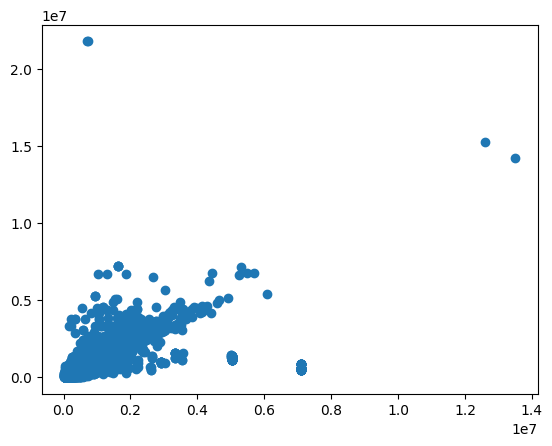

In [12]:
plt.scatter(Assesed_And_Sale_Price_Data["board_tot"],Assesed_And_Sale_Price_Data["sale_price"])

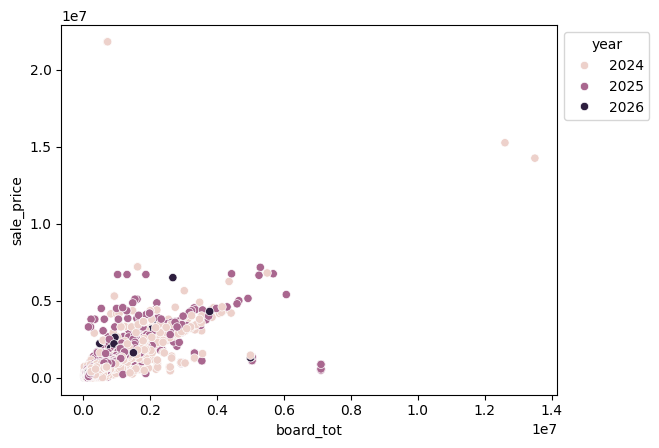

In [13]:
ax = sns.scatterplot(data=Assesed_And_Sale_Price_Data, x="board_tot", y="sale_price", hue="year")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [14]:
OutlierRemoved = Assesed_And_Sale_Price_Data[Assesed_And_Sale_Price_Data["sale_price"]<2*10**7]

In [15]:
Residuals = OutlierRemoved["sale_price"] - OutlierRemoved["board_tot"]

In [16]:
print(Residuals)

0        -19000
1        -45000
2        101100
3         79180
4         79180
          ...  
20395       -10
20396    -70010
20397       900
20398       -10
20399    198970
Length: 20398, dtype: object


In [17]:
OutlierRemoved['residuals'] = Residuals


/var/folders/1b/573lr61127ncj8f1y_y8vgww0000gn/T/ipykernel_35111/614094280.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  OutlierRemoved['residuals'] = Residuals


(array([3.9000e+01, 0.0000e+00, 4.6000e+01, 2.9000e+01, 1.0600e+02,
        1.9924e+04, 1.9700e+02, 3.5000e+01, 1.5000e+01, 7.0000e+00]),
 array([-6606230., -5378407., -4150584., -2922761., -1694938.,  -467115.,
          760708.,  1988531.,  3216354.,  4444177.,  5672000.]),
 <BarContainer object of 10 artists>)

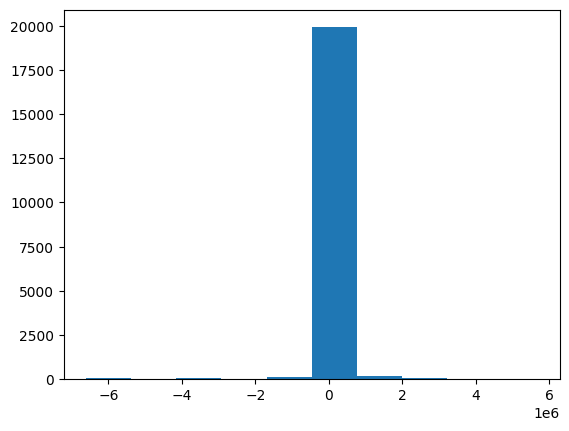

In [20]:
plt.hist(Residuals)

In [18]:
print(np.mean(Residuals), np.std(Residuals))

63247.013383665064 427971.7348858089


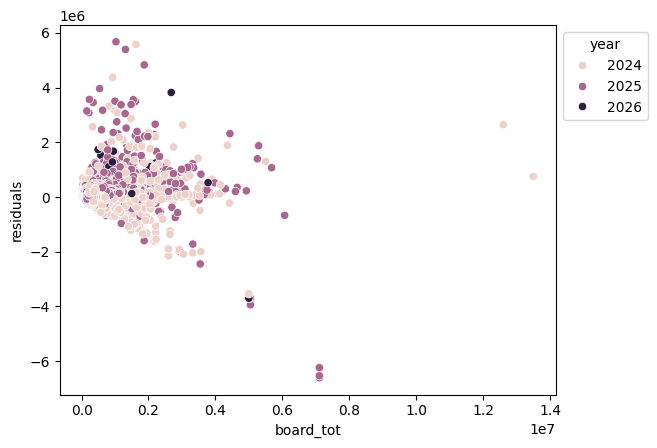

In [19]:
ax = sns.scatterplot(data=OutlierRemoved, x="board_tot", y="residuals", hue="year")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

We see that the residuals have mean ~63,000 and a standard deviation of 427,941. These variations are far too high to treat them as more or less the same variable and the mean suggests that sale price is typically meaningfully higher than the assessed value for taxation purposes. Hence as our models will want to approximate the "value" of the house, it will be necessary to justify using one notion of value over another. Sale price should be the target variable we are wanting to model if our key demographic is new homebuyers, assessed value may be more useful if we are looking at taxes as a part of cost of living.